# AI Assistant: Plain-Language Weather Guidance from METAR Data

This notebook builds on the query workflow from `0_Intro` and `2_Interactive_Viz`.
It takes structured METAR observations and translates them into **plain-language,
actionable weather guidance for non-expert users**, such as farmers and ranchers.

A key design principle: when data is missing or sparse, the assistant communicates
that limitation **honestly** rather than fabricating a confident answer. This
reflects responsible-AI practice for non-expert audiences.

In [1]:
import duckdb
import pandas as pd
from datetime import datetime, timedelta

# --- Pick a time (global snapshot: ALL stations at this hour) ---
year, month, day, hour = 2026, 1, 1, 0   # a past hour known to have data

time_1 = datetime(year, month, day, hour)
time_0 = time_1 - timedelta(hours=1)

# Build the data URLs (handles the year-boundary edge case)
YYYY_0, YYYY_1 = time_0.strftime("%Y"), time_1.strftime("%Y")
base = "https://data.source.coop/dynamical/asos-parquet"
if YYYY_0 == YYYY_1:
    URLs = [f"{base}/year={YYYY_1}/data.parquet"]
else:
    URLs = [f"{base}/year={YYYY_0}/data.parquet",
            f"{base}/year={YYYY_1}/data.parquet"]

# Query ALL stations worldwide for that hour
df = duckdb.execute("""
    SELECT valid, station, name, country, tmpf, dwpf, sknt, p01i, longitude, latitude
    FROM read_parquet($1, hive_partitioning=true)
    WHERE valid BETWEEN $2 AND $3
    ORDER BY country
""", [URLs, time_0, time_1]).fetchdf()

print(f"Retrieved {len(df)} station records for {time_1} UTC")
print(f"Countries represented: {df['country'].nunique()}")
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Retrieved 7787 station records for 2026-01-01 00:00:00 UTC
Countries represented: 14


,valid,station,name,country,tmpf,dwpf,sknt,p01i,longitude,latitude
0,2025-12-31 23:00:00+00:00,YSDU,Dubbo,AU,77.0,53.6,15.0,0.0,148.5747,-32.2167
1,2025-12-31 23:30:00+00:00,YWLM,Newcastle,AU,71.6,62.6,9.0,0.0,151.8344,-32.7950
2,2025-12-31 23:00:00+00:00,NZQN,Queenstown,AU,62.6,53.6,6.0,0.0,168.7392,-45.0211
3,2026-01-01 00:00:00+00:00,NZQN,Queenstown,AU,64.4,53.6,4.0,0.0,168.7392,-45.0211
4,2025-12-31 23:00:00+00:00,YPPD,Port Hedland,AU,87.8,68.0,13.0,0.0,118.6317,-20.3725


In [2]:
def extract_observation(df, station_code="DEN"):
    """From the global query result, pull one representative station's observation.
    Returns a dict; missing values become None so we can handle them honestly."""
    if df is None or len(df) == 0:
        return None  # no data at all

    # Filter the global dataframe down to our chosen station
    station_rows = df[df["station"] == station_code]
    if len(station_rows) == 0:
        return None  # this station not present in the data

    row = station_rows.iloc[-1]  # most recent observation for that station

    def safe(val):
        return None if pd.isna(val) else val

    return {
        "station": safe(row.get("station")),
        "name": safe(row.get("name")),
        "country": safe(row.get("country")),
        "time": str(safe(row.get("valid"))),
        "temp_f": safe(row.get("tmpf")),
        "dewpoint_f": safe(row.get("dwpf")),
        "wind_kt": safe(row.get("sknt")),
        "precip_in": safe(row.get("p01i")),
    }

# Denver as our representative station for plain-language guidance
obs = extract_observation(df, station_code="DEN")
obs

{'station': 'DEN',
 'name': 'DENVER INTNL ARPT',
 'country': 'US',
 'time': '2025-12-31 23:53:00+00:00',
 'temp_f': np.float64(57.0),
 'dewpoint_f': np.float64(15.0),
 'wind_kt': np.float64(4.0),
 'precip_in': np.float64(0.0)}

In [3]:
def generate_guidance_rule_based(obs):
    """Plain-language weather guidance for non-expert (e.g. agricultural) users.
    Honestly flags missing data instead of guessing."""
    if obs is None:
        return ("No weather observations were found for this station and time. "
                "I can't provide guidance without data — please try a nearby "
                "station or a different time.")

    where = obs["name"] or obs["station"] or "this location"
    lines = [f"Weather guidance for {where} (observed {obs['time']}):", ""]

    # Temperature
    if obs["temp_f"] is not None:
        t = obs["temp_f"]
        note = ""
        if t <= 32:
            note = " Freezing conditions — protect sensitive crops and livestock water."
        elif t >= 90:
            note = " Hot — ensure livestock have shade and water; avoid midday field labor."
        else:
            note = " Mild conditions, generally favorable for outdoor field work."
        lines.append(f"• Temperature: {t:.0f}°F.{note}")

    # Wind
    if obs["wind_kt"] is not None:
        mph = obs["wind_kt"] * 1.15
        note = " Too windy for safe spraying." if mph >= 10 else " Calm enough for spraying."
        lines.append(f"• Wind: about {mph:.0f} mph.{note}")
    else:
        lines.append("• Wind: not reported — do not assume calm conditions before spraying.")

    # Precipitation
    if obs["precip_in"] is not None:
        p = obs["precip_in"]
        note = " Recent rainfall — fields may be wet." if p > 0 else " No recent precipitation recorded."
        lines.append(f"• Precipitation (last hour): {p:.2f} in.{note}")
    else:
        lines.append("• Precipitation: not reported for this hour.")

    lines.append("")
    lines.append("Note: This guidance is based only on the available observations above. "
                 "Where a value is missing, no assumption has been made.")
    return "\n".join(lines)

print(generate_guidance_rule_based(obs))

Weather guidance for DENVER INTNL ARPT (observed 2025-12-31 23:53:00+00:00):

• Temperature: 57°F. Mild conditions, generally favorable for outdoor field work.
• Wind: about 5 mph. Calm enough for spraying.
• Precipitation (last hour): 0.00 in. No recent precipitation recorded.

Note: This guidance is based only on the available observations above. Where a value is missing, no assumption has been made.


## Visualizing the raw observation

Before translating the data into plain language, here is what a single station's
raw observation looks like. This is the kind of numeric output that is accurate
but hard for a non-expert user to act on directly.

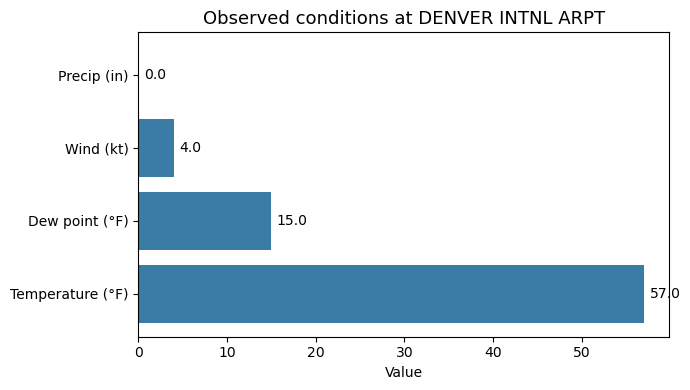

In [4]:
import matplotlib.pyplot as plt

# Build a simple bar chart of the current observation's key fields
fields = []
values = []
if obs is not None:
    if obs["temp_f"] is not None:
        fields.append("Temperature (°F)"); values.append(obs["temp_f"])
    if obs["dewpoint_f"] is not None:
        fields.append("Dew point (°F)"); values.append(obs["dewpoint_f"])
    if obs["wind_kt"] is not None:
        fields.append("Wind (kt)"); values.append(obs["wind_kt"])
    if obs["precip_in"] is not None:
        fields.append("Precip (in)"); values.append(obs["precip_in"])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(fields, values, color="#3a7ca5")
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_title(f"Observed conditions at {obs['name'] or obs['station']}", fontsize=13)
ax.set_xlabel("Value")
plt.tight_layout()
plt.show()

## Visualizing data coverage — why honesty matters

This global snapshot returned thousands of station records, but they come from only
a small number of countries. The chart below shows how many stations report from
each country at this hour, revealing that vast regions of the world are simply
absent from this data source. (The maintainers have confirmed the current ASOS
Parquet source covers only a handful of countries.)

This is exactly why the assistant is designed to **flag missing data rather than
fabricate it**: if a user asks about a location with no coverage, a responsible
assistant must say so, not invent a plausible-sounding answer.

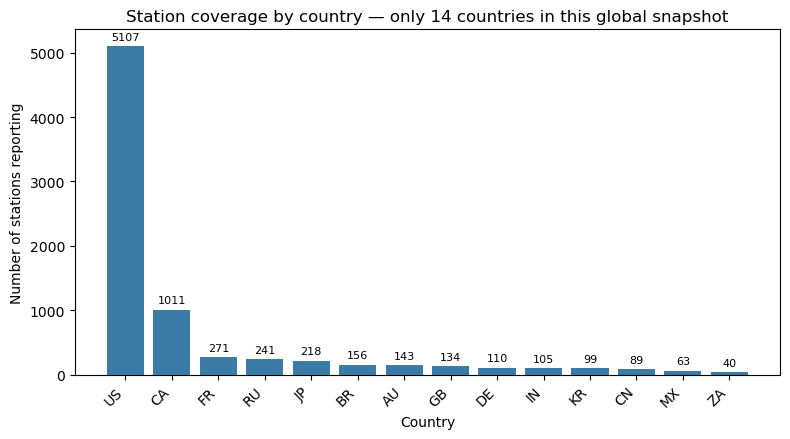

This hour's data covers 14 countries: AU, BR, CA, CN, DE, FR, GB, IN, JP, KR, MX, RU, US, ZA


In [5]:
import matplotlib.pyplot as plt

# How many stations report from each country in this global snapshot?
country_counts = df["country"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(country_counts.index, country_counts.values, color="#3a7ca5")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
ax.set_title(f"Station coverage by country — only {df['country'].nunique()} countries "
             f"in this global snapshot", fontsize=12)
ax.set_xlabel("Country")
ax.set_ylabel("Number of stations reporting")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"This hour's data covers {df['country'].nunique()} countries: "
      f"{', '.join(sorted(df['country'].unique()))}")

## Mapping the coverage gap

The bar chart above counts stations per country. Plotting those same stations on a
world map makes the gap unmistakable: dense clusters over North America, with vast
empty regions across Africa, South America, and much of Asia. For a non-expert user
asking about weather in an uncovered region, there is simply no data to answer with,
which is exactly why the assistant must report gaps honestly.

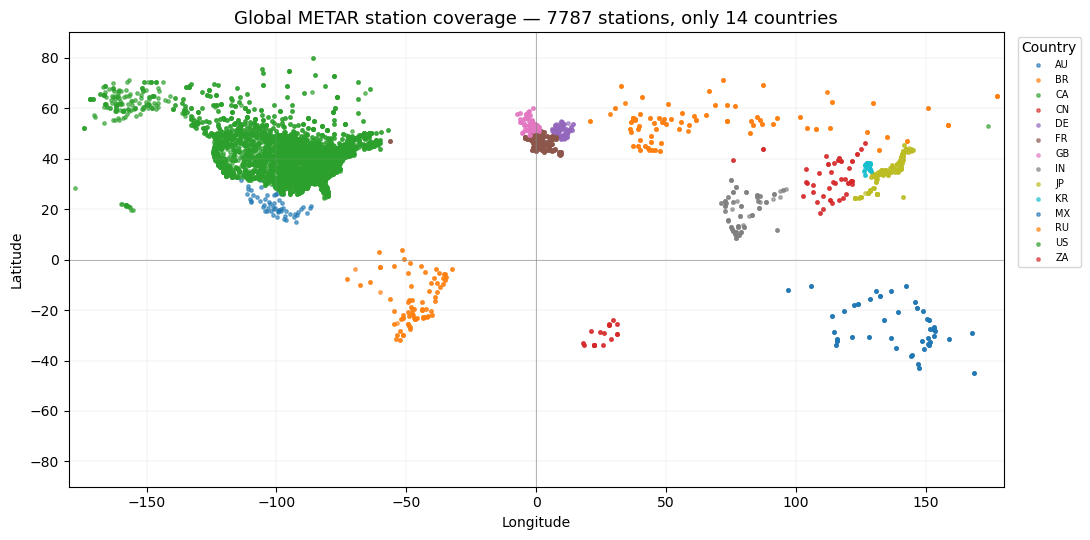

In [6]:
import matplotlib.pyplot as plt

# Plot every reporting station by its lon/lat, colored by country
fig, ax = plt.subplots(figsize=(11, 5.5))

for country, group in df.groupby("country"):
    ax.scatter(group["longitude"], group["latitude"],
               s=6, alpha=0.6, label=country)

ax.set_title(f"Global METAR station coverage — {len(df)} stations, "
             f"only {df['country'].nunique()} countries", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.axhline(0, color="gray", lw=0.4)   # equator reference line
ax.axvline(0, color="gray", lw=0.4)   # prime meridian reference line
ax.grid(True, linewidth=0.3, alpha=0.4)
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=7, ncol=1)
plt.tight_layout()
plt.show()

In [7]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "geodatasets", "--quiet"])
print("done")

done


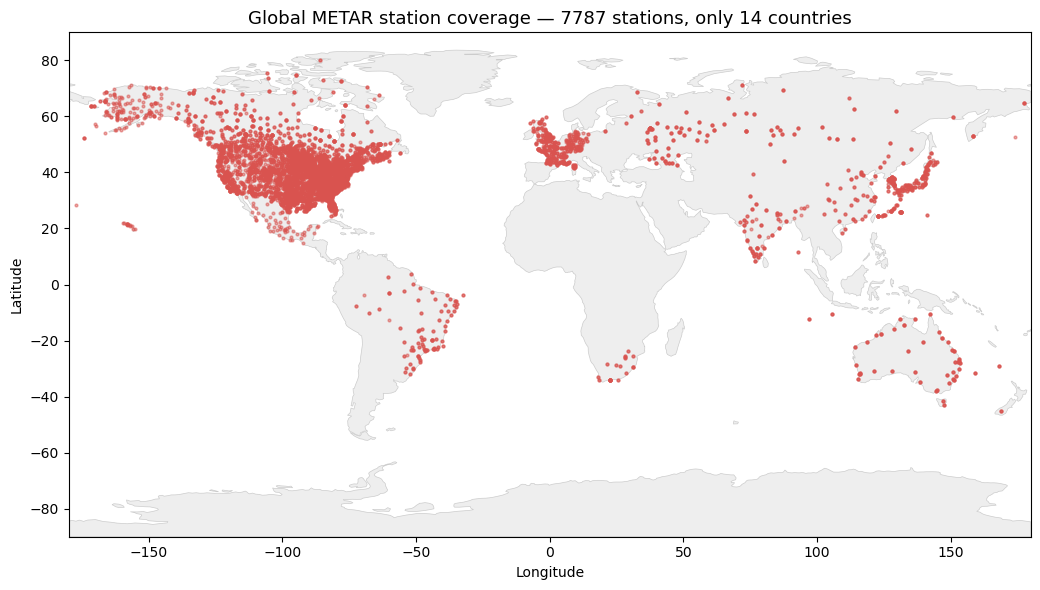

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import geodatasets

# Load a world basemap via geodatasets
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color="#eeeeee", edgecolor="#cccccc", linewidth=0.5)
gdf.plot(ax=ax, markersize=4, color="#d9534f", alpha=0.5)
ax.set_title(f"Global METAR station coverage — {len(df)} stations, "
             f"only {df['country'].nunique()} countries", fontsize=13)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
plt.tight_layout()
plt.show()

### Demonstration: honest handling of missing and partial data

A core feature of this assistant is that it never fabricates values. Below,
the first example shows the response when **no data** is available; the second
shows **partial data** (temperature present, wind missing), where the assistant
explicitly flags what it cannot confirm.

In [9]:
# Demonstrate honest handling of missing data:
# query a station/time unlikely to have data, and show the assistant does NOT fabricate.

obs_missing = None  # simulate "no observation found"
print(generate_guidance_rule_based(obs_missing))
print("\n" + "="*50 + "\n")

# Also show partial data: temperature present, wind missing
obs_partial = {
    "station": "TEST", "name": "Example Ranch", "country": "US",
    "time": "2026-01-01 00:00", "temp_f": 28.0,
    "dewpoint_f": None, "wind_kt": None, "precip_in": None
}
print(generate_guidance_rule_based(obs_partial))

No weather observations were found for this station and time. I can't provide guidance without data — please try a nearby station or a different time.


Weather guidance for Example Ranch (observed 2026-01-01 00:00):

• Temperature: 28°F. Freezing conditions — protect sensitive crops and livestock water.
• Wind: not reported — do not assume calm conditions before spraying.
• Precipitation: not reported for this hour.

Note: This guidance is based only on the available observations above. Where a value is missing, no assumption has been made.


## Summary

This notebook demonstrates an AI-assistant layer that sits on top of the METAR
query workflow and translates raw surface observations into plain-language,
actionable guidance for non-expert users such as farmers and ranchers.

Key points:

- **From data to decisions.** Raw fields like wind in knots or temperature in
  Fahrenheit are converted into practical advice (spraying conditions, frost risk,
  livestock considerations).
- **Honest handling of gaps.** The assistant never fabricates values. When a field
  is missing, it says so, important because this archive has uneven coverage. The data source covers only a small number of countries (this particular global snapshot contained just 14) and has frequent missing fields.
- **Reproducible and offline by design.** The guidance uses a transparent
  rule-based approach with no external API calls, making the notebook fully
  reproducible in a shared environment. A future extension could pass the same
  structured observation to a large language model for richer natural language,
  given secure credential handling.

This lowers the technical barrier to using observational weather data and shows how
responsible-AI principles apply when outputs may inform real-world decisions.